# Reconocimiento del número 6 con MNIST

Este notebook entrena un clasificador binario para responder una pregunta concreta:

$$\text{¿La imagen contiene un 6?}$$

Las etiquetas originales de MNIST (0 a 9) se transforman en:

- `1`: la imagen es un **6**.
- `0`: la imagen **no es un 6**.

Se utiliza `SGDClassifier` con pérdida logística. Este modelo permite observar el entrenamiento época por época y funciona bien con las 70.000 imágenes de MNIST sin requerir TensorFlow.

## 1. Instalación

Ejecuta esta celda una sola vez. Si acabas de instalar la librería, reinicia el kernel antes de continuar.

## 2. Librerías y semilla

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import train_test_split

SEED = 42
rng = np.random.default_rng(SEED)


## 3. Descargar MNIST

La primera ejecución descarga aproximadamente 70.000 imágenes y puede tardar algunos minutos. Las siguientes ejecuciones usan la copia almacenada en caché.

Cada imagen tiene 28×28 píxeles. OpenML la entrega como una fila de 784 características.

In [5]:
print("Cargando MNIST. La primera vez puede tardar unos minutos...")
start_time = time.time()

mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X = mnist.data.astype(np.float32) / 255.0
y_original = mnist.target.astype(np.int8)

# Problema binario: 1 solamente cuando el dígito es 6.
y = (y_original == 6).astype(np.int8)

print(f"Carga terminada en {time.time() - start_time:.1f} segundos")
print("Forma de X:", X.shape)
print("Cantidad de imágenes que son 6:", int(y.sum()))
print("Cantidad de imágenes que no son 6:", int((y == 0).sum()))


Cargando MNIST. La primera vez puede tardar unos minutos...


C:\Users\zapatama\AppData\Roaming\Python\Python312\site-packages\sklearn\datasets\_openml.py:74: RuntimeWarning: Invalid cache, redownloading file
  warn("Invalid cache, redownloading file", RuntimeWarning)


Carga terminada en 324.1 segundos
Forma de X: (70000, 784)
Cantidad de imágenes que son 6: 6876
Cantidad de imágenes que no son 6: 63124


## 4. Conocer los datos

Mostramos ejemplos aleatorios con su etiqueta binaria. El título verde indica que la imagen pertenece a la clase que queremos reconocer.

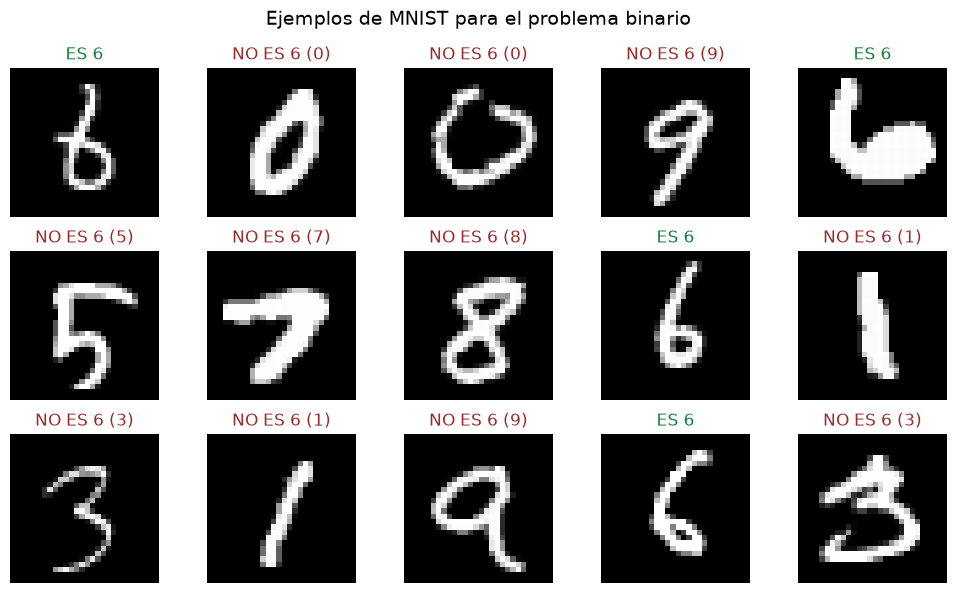

In [6]:
indices = rng.choice(len(X), size=15, replace=False)
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    is_six = bool(y[idx])
    ax.set_title("ES 6" if is_six else f"NO ES 6 ({y_original[idx]})",
                 color="#16803c" if is_six else "#9b2c2c")
    ax.axis("off")

plt.suptitle("Ejemplos de MNIST para el problema binario", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Separación de entrenamiento y prueba

Se conserva la proporción de números 6 mediante `stratify`. La prueba no participa en el aprendizaje y representa imágenes nuevas para el modelo.

In [7]:
X_train, X_test, y_train, y_test, digit_train, digit_test = train_test_split(
    X,
    y,
    y_original,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print("Entrenamiento:", X_train.shape, "| positivos:", int(y_train.sum()))
print("Prueba:       ", X_test.shape, "| positivos:", int(y_test.sum()))


Entrenamiento: (56000, 784) | positivos: 5501
Prueba:        (14000, 784) | positivos: 1375


## 6. Entrenamiento época por época

`partial_fit` permite recorrer varias veces los datos. En cada época se mezclan las imágenes y se calculan:

- **Precisión**: de las imágenes señaladas como 6, cuántas realmente lo eran.
- **Recall**: de todos los 6 reales, cuántos encontró el modelo.
- **F1**: equilibrio entre precisión y recall.

Se usa `class_weight="balanced"` porque los 6 son una minoría frente a los otros nueve dígitos.

In [8]:
weight_no_six = len(y_train) / (2 * np.sum(y_train == 0))
weight_six = len(y_train) / (2 * np.sum(y_train == 1))
class_weights = {0: weight_no_six, 1: weight_six}
print("Pesos de clase:", class_weights)

model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-4,
    learning_rate="optimal",
    class_weight=class_weights,
    random_state=SEED,
)

EPOCHS = 12
history = {"precision": [], "recall": [], "f1": []}
classes = np.array([0, 1], dtype=np.int8)

for epoch in range(1, EPOCHS + 1):
    order = rng.permutation(len(X_train))
    model.partial_fit(X_train[order], y_train[order], classes=classes)

    predictions = model.predict(X_test)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    history["precision"].append(precision)
    history["recall"].append(recall)
    history["f1"].append(f1)
    print(f"Época {epoch:02}/{EPOCHS} | precisión={precision:.4f} "
          f"| recall={recall:.4f} | F1={f1:.4f}")


Pesos de clase: {0: np.float64(0.5544664250777243), 1: np.float64(5.0899836393383024)}
Época 01/12 | precisión=0.8045 | recall=0.9607 | F1=0.8757
Época 02/12 | precisión=0.8080 | recall=0.9644 | F1=0.8793
Época 03/12 | precisión=0.5931 | recall=0.9818 | F1=0.7395
Época 04/12 | precisión=0.7588 | recall=0.9767 | F1=0.8541
Época 05/12 | precisión=0.8363 | recall=0.9622 | F1=0.8948
Época 06/12 | precisión=0.7229 | recall=0.9811 | F1=0.8325
Época 07/12 | precisión=0.7583 | recall=0.9767 | F1=0.8538
Época 08/12 | precisión=0.8460 | recall=0.9549 | F1=0.8972
Época 09/12 | precisión=0.7973 | recall=0.9724 | F1=0.8761
Época 10/12 | precisión=0.7768 | recall=0.9745 | F1=0.8645
Época 11/12 | precisión=0.5824 | recall=0.9898 | F1=0.7333
Época 12/12 | precisión=0.8627 | recall=0.9549 | F1=0.9065


## 7. Evolución del aprendizaje

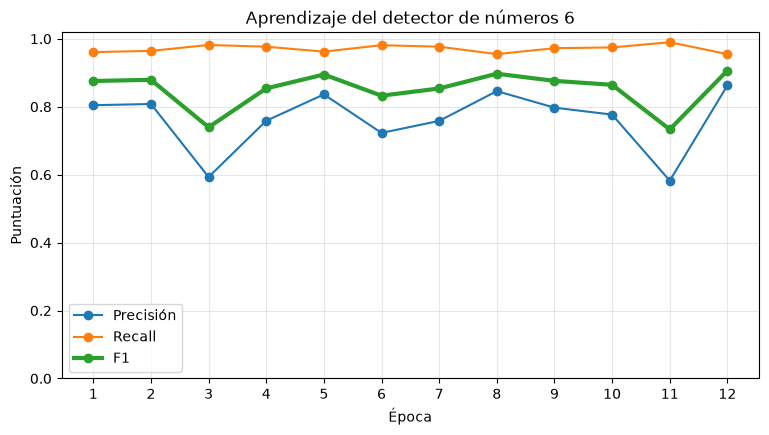

In [9]:
epochs = np.arange(1, EPOCHS + 1)
plt.figure(figsize=(9, 4.5))
plt.plot(epochs, history["precision"], marker="o", label="Precisión")
plt.plot(epochs, history["recall"], marker="o", label="Recall")
plt.plot(epochs, history["f1"], marker="o", linewidth=3, label="F1")
plt.ylim(0, 1.02)
plt.xticks(epochs)
plt.xlabel("Época")
plt.ylabel("Puntuación")
plt.title("Aprendizaje del detector de números 6")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 8. Evaluación final

En este problema, la clase positiva `1` es **ES 6**. La matriz de confusión permite distinguir falsos positivos y falsos negativos.

              precision    recall  f1-score   support

     NO ES 6     0.9950    0.9834    0.9892     12625
        ES 6     0.8627    0.9549    0.9065      1375

    accuracy                         0.9806     14000
   macro avg     0.9289    0.9692    0.9478     14000
weighted avg     0.9820    0.9806    0.9811     14000



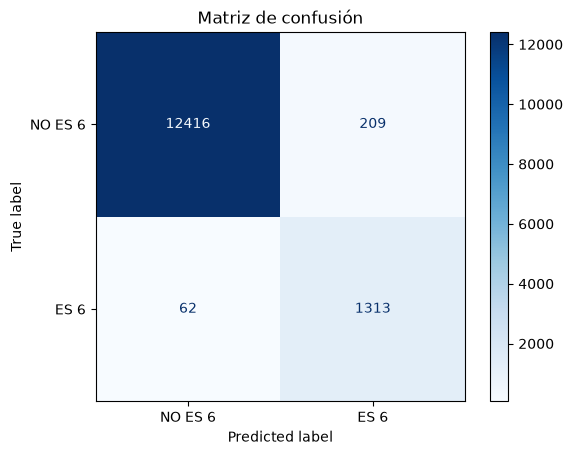

In [10]:
y_pred = model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=["NO ES 6", "ES 6"],
    digits=4,
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["NO ES 6", "ES 6"],
    cmap="Blues",
    values_format="d",
)
plt.title("Matriz de confusión")
plt.show()


## 9. Predicciones con nivel de confianza

La regresión logística devuelve una probabilidad estimada de que cada imagen sea un 6. Aquí se muestran casos variados ordenados por confianza.

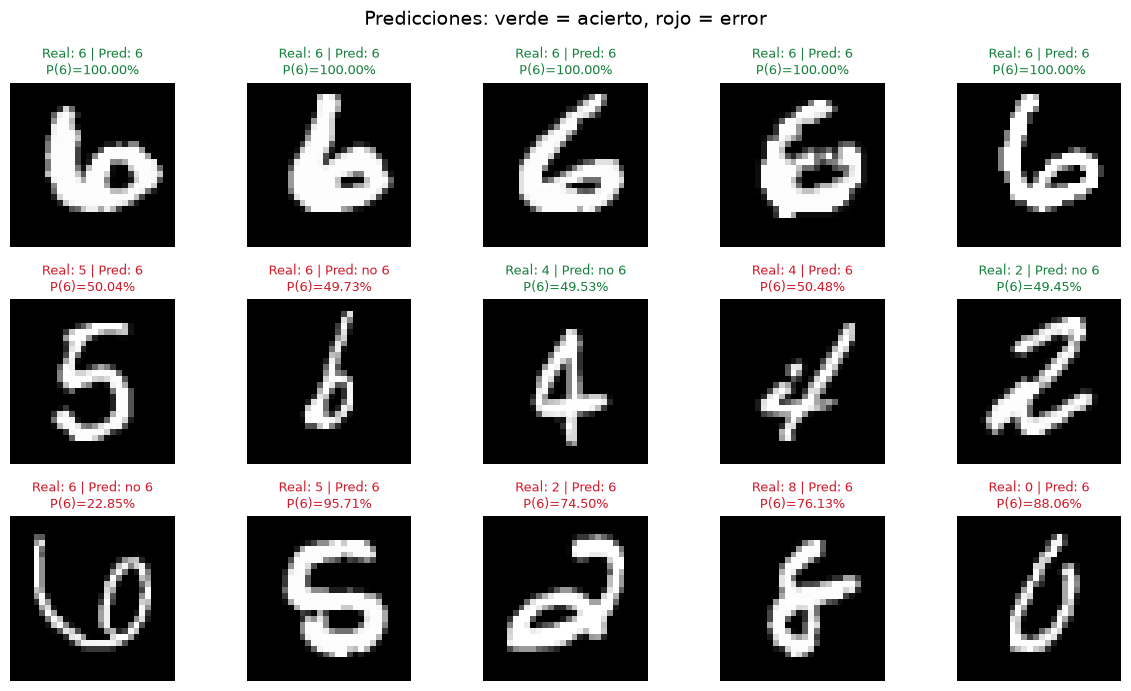

In [11]:
probabilities = model.predict_proba(X_test)[:, 1]

# Combinar imágenes muy seguras, dudosas y errores para una muestra interesante.
high_six = np.argsort(probabilities)[-5:][::-1]
doubtful = np.argsort(np.abs(probabilities - 0.5))[:5]
errors = np.flatnonzero(y_pred != y_test)
chosen_errors = errors[:5] if len(errors) >= 5 else errors
selected = np.concatenate([high_six, doubtful, chosen_errors])[:15]

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for ax, idx in zip(axes.ravel(), selected):
    predicted_text = "6" if y_pred[idx] else "no 6"
    correct = y_pred[idx] == y_test[idx]
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(
        f"Real: {digit_test[idx]} | Pred: {predicted_text}\nP(6)={probabilities[idx]:.2%}",
        color="#16803c" if correct else "#d11a2a",
        fontsize=9,
    )
    ax.axis("off")

for ax in axes.ravel()[len(selected):]:
    ax.axis("off")
plt.suptitle("Predicciones: verde = acierto, rojo = error", fontsize=14)
plt.tight_layout()
plt.show()


## 10. Probar una imagen de MNIST individual

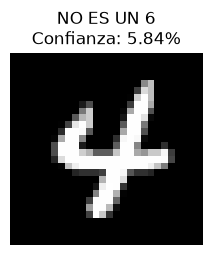

Resultado: False | Probabilidad de ser 6: 0.0584


In [12]:
def recognize_six(image, trained_model=model, show=True):
    # Recibe una imagen de 28 por 28 o un vector de 784 valores.
    image = np.asarray(image, dtype=np.float32)
    if image.max() > 1:
        image = image / 255.0
    vector = image.reshape(1, -1)
    probability = trained_model.predict_proba(vector)[0, 1]
    result = probability >= 0.5

    if show:
        plt.figure(figsize=(2.5, 2.5))
        plt.imshow(vector.reshape(28, 28), cmap="gray")
        plt.title(f"{'ES UN 6' if result else 'NO ES UN 6'}\nConfianza: {probability:.2%}")
        plt.axis("off")
        plt.show()
    return result, probability


example_index = 10
is_six, confidence = recognize_six(X_test[example_index])
print("Resultado:", is_six, "| Probabilidad de ser 6:", round(confidence, 4))


## Conclusiones

1. MNIST se convirtió de un problema de diez clases a uno binario: `6` contra `no 6`.
2. El modelo aprende directamente de los valores de los 784 píxeles.
3. El seguimiento por épocas muestra si la detección mejora y cuándo deja de hacerlo.
4. La precisión y el recall son más informativos que la exactitud general porque la clase `6` es minoritaria.
5. Los falsos positivos muestran dígitos que se parecen visualmente a un 6; los falsos negativos muestran variantes de escritura que el modelo todavía confunde.